<a href="https://colab.research.google.com/github/ekuelkpodar/Researchers/blob/main/Chemistry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exploratory Data Analysis
We will start by loading the dataset and checking its structure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Load the dataset
df = pd.read_csv('/content/chemist.csv')

# Display basic information and first few rows
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15635 entries, 0 to 15634
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   explore href       15635 non-null  object
 1   item-link          15635 non-null  object
 2   card-view-value    15635 non-null  object
 3   card-view-title 3  15635 non-null  object
 4   card-view-value 2  15635 non-null  object
 5   card-view-title 4  15635 non-null  object
 6   card-view-value 3  15635 non-null  object
 7   card-view-title 5  14952 non-null  object
 8   card-view-value 4  14952 non-null  object
 9   card-view-title 6  13635 non-null  object
 10  card-view-value 5  13626 non-null  object
 11  card-view-title 7  8996 non-null   object
 12  card-view-value 6  8987 non-null   object
dtypes: object(13)
memory usage: 1.6+ MB
None


,explore href,item-link,card-view-value,card-view-title 3,card-view-value 2,card-view-title 4,card-view-value 3,card-view-title 5,card-view-value 4,card-view-title 6,card-view-value 5,card-view-title 7,card-view-value 6
0,http://www.wikidata.org/entity/Q13104787,wd:Q13104787,Q13104787,birthDate,11 August 1915,deathDate,4 May 2001,countryLabel,Luxembourg,occupationLabel,chemist,wikipediaURL,https://en.wikipedia.org/wiki/Ren%C3%A9_Weiss
1,http://www.wikidata.org/entity/Q132170206,wd:Q132170206,Q132170206,countryLabel,Switzerland,occupationLabel,chemist,wikipediaURL,https://en.wikipedia.org/wiki/Daniel_Trachsel,NaN,NaN,NaN,NaN
2,http://www.wikidata.org/entity/Q13520818,wd:Q13520818,Q13520818,birthDate,24 May 1974,countryLabel,Germany,occupationLabel,biochemist,wikipediaURL,https://en.wikipedia.org/wiki/Magnus_Manske,NaN,NaN
3,http://www.wikidata.org/entity/Q137589983,wd:Q137589983,Q137589983,occupationLabel,chemical engineer,wikipediaURL,https://en.wikipedia.org/wiki/Allyson_Ee,NaN,NaN,NaN,NaN,NaN,NaN
4,http://www.wikidata.org/entity/Q138314524,wd:Q138314524,Q138314524,birthDate,19 March 1882,deathDate,2 October 1943,countryLabel,German Reich,occupationLabel,chemist,wikipediaURL,https://en.wikipedia.org/wiki/Wilhelm_Meiser


### Visualizing Data Distributions
Let's visualize some interesting aspects of the data, such as common fields or categories.

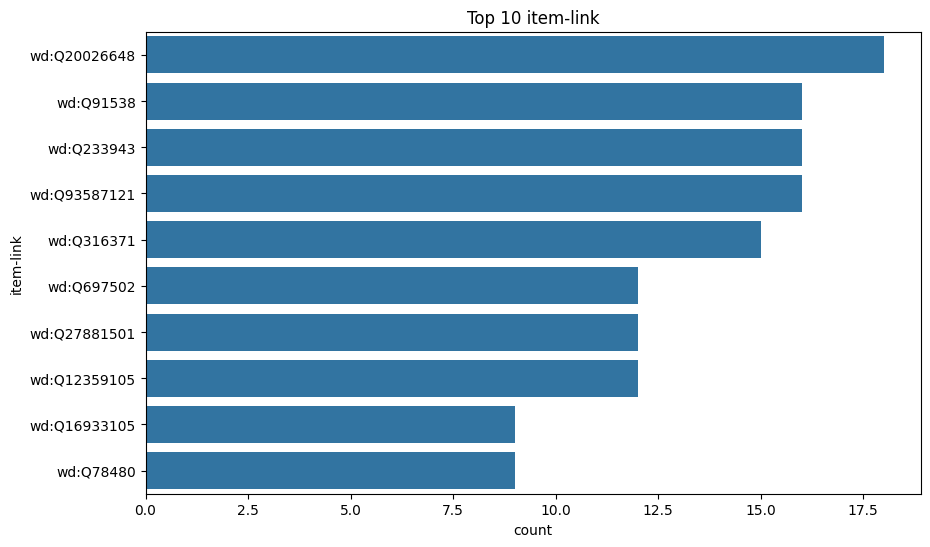

In [2]:
# Example visualization: Distribution of a categorical column (assuming 'category' or 'field' exists)
# We'll select the top 10 most frequent entries if the column exists
column_to_plot = df.columns[1] # Using the second column as a generic target for exploration
plt.figure(figsize=(10, 6))
sns.countplot(y=column_to_plot, data=df, order=df[column_to_plot].value_counts().iloc[:10].index)
plt.title(f'Top 10 {column_to_plot}')
plt.show()

### Network Analysis
We will now use `networkx` to represent relationships. For example, we can link biologists if they share a specific attribute (like the same field or nationality).

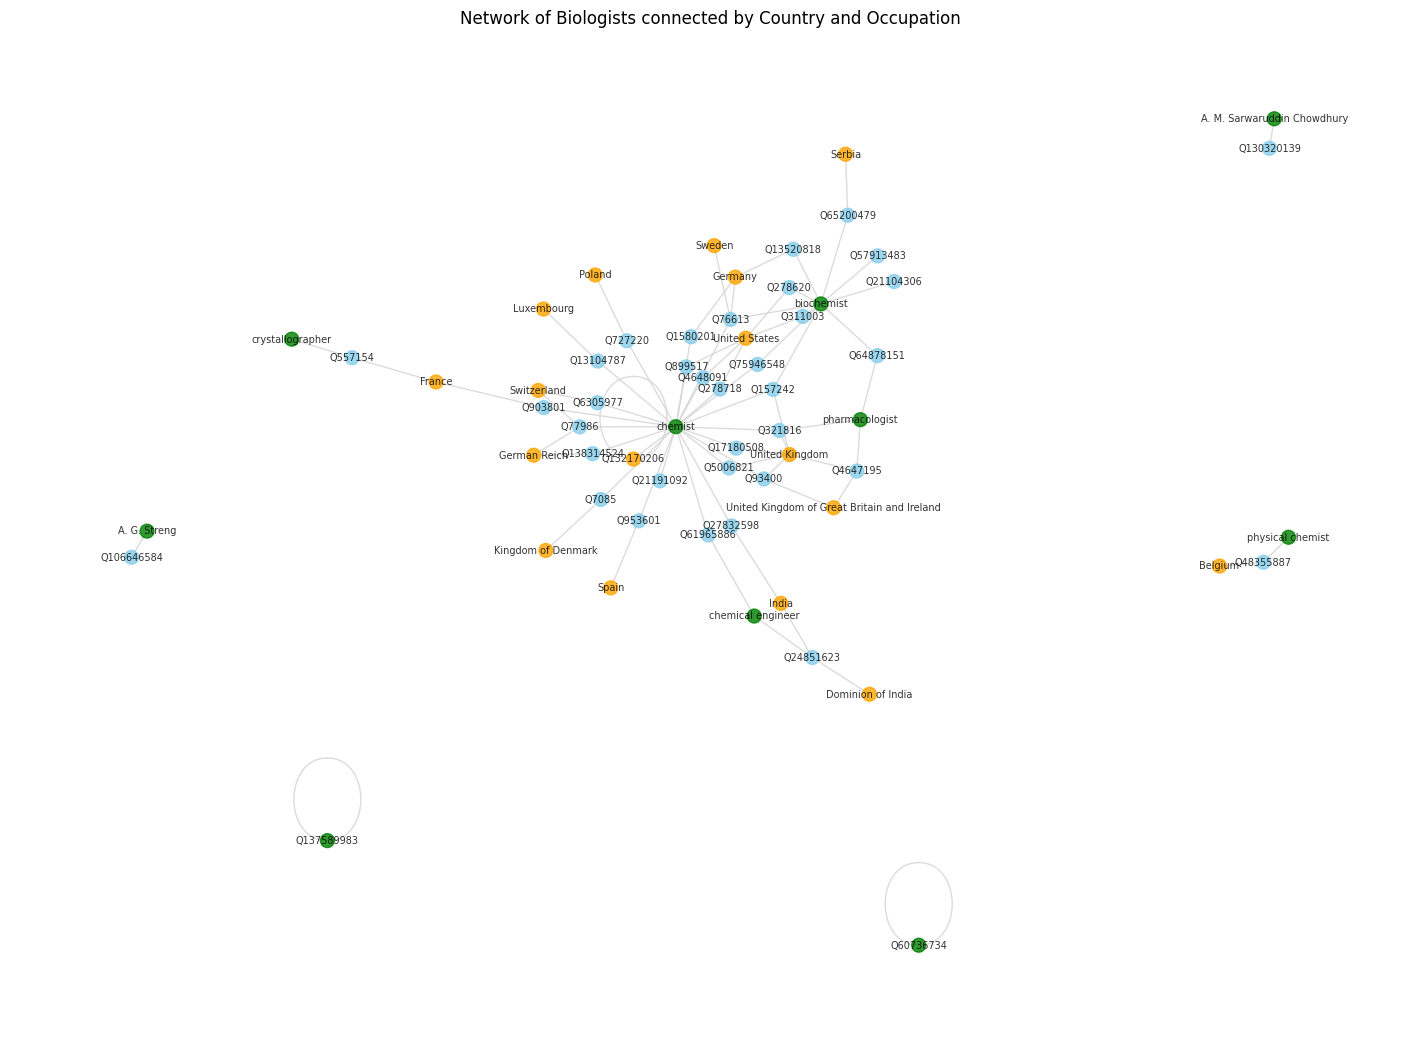

In [4]:
# Refined Network Analysis: Linking biologists to their countries and occupations
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Helper to find a value based on a title in the card-view columns
def get_val(row, title_to_find):
    for i in range(3, 8):
        title_col = f'card-view-title {i}' if i > 3 else 'card-view-title 3'
        val_col = f'card-view-value {i-1}' if i > 3 else 'card-view-value'
        if title_col in row and row[title_col] == title_to_find:
            return row[val_col]
    return None

# Process a subset for clarity in visualization
subset = df.head(50)
for _, row in subset.iterrows():
    name = str(row['explore href']).split('/')[-1]
    country = get_val(row, 'countryLabel')
    occ = get_val(row, 'occupationLabel')

    G.add_node(name, type='biologist', color='skyblue')
    if country and pd.notna(country):
        G.add_node(country, type='country', color='orange')
        G.add_edge(name, country)
    if occ and pd.notna(occ):
        G.add_node(occ, type='occupation', color='green')
        G.add_edge(name, occ)

# Plotting
plt.figure(figsize=(14, 10))
node_colors = [nx.get_node_attributes(G, 'color').get(node, 'lightgray') for node in G.nodes()]
pos = nx.spring_layout(G, k=0.15, seed=42)
nx.draw(G, pos, with_labels=True, node_size=100, font_size=7, node_color=node_colors, edge_color='lightgray', alpha=0.8)
plt.title('Network of Biologists connected by Country and Occupation')
plt.show()

### Advanced Network Clustering
We will now use community detection to find clusters of biologists that share similar professional and geographic profiles. We will also calculate 'betweenness centrality' to find the most influential entities in the network.

In [2]:
!pip install python-louvain

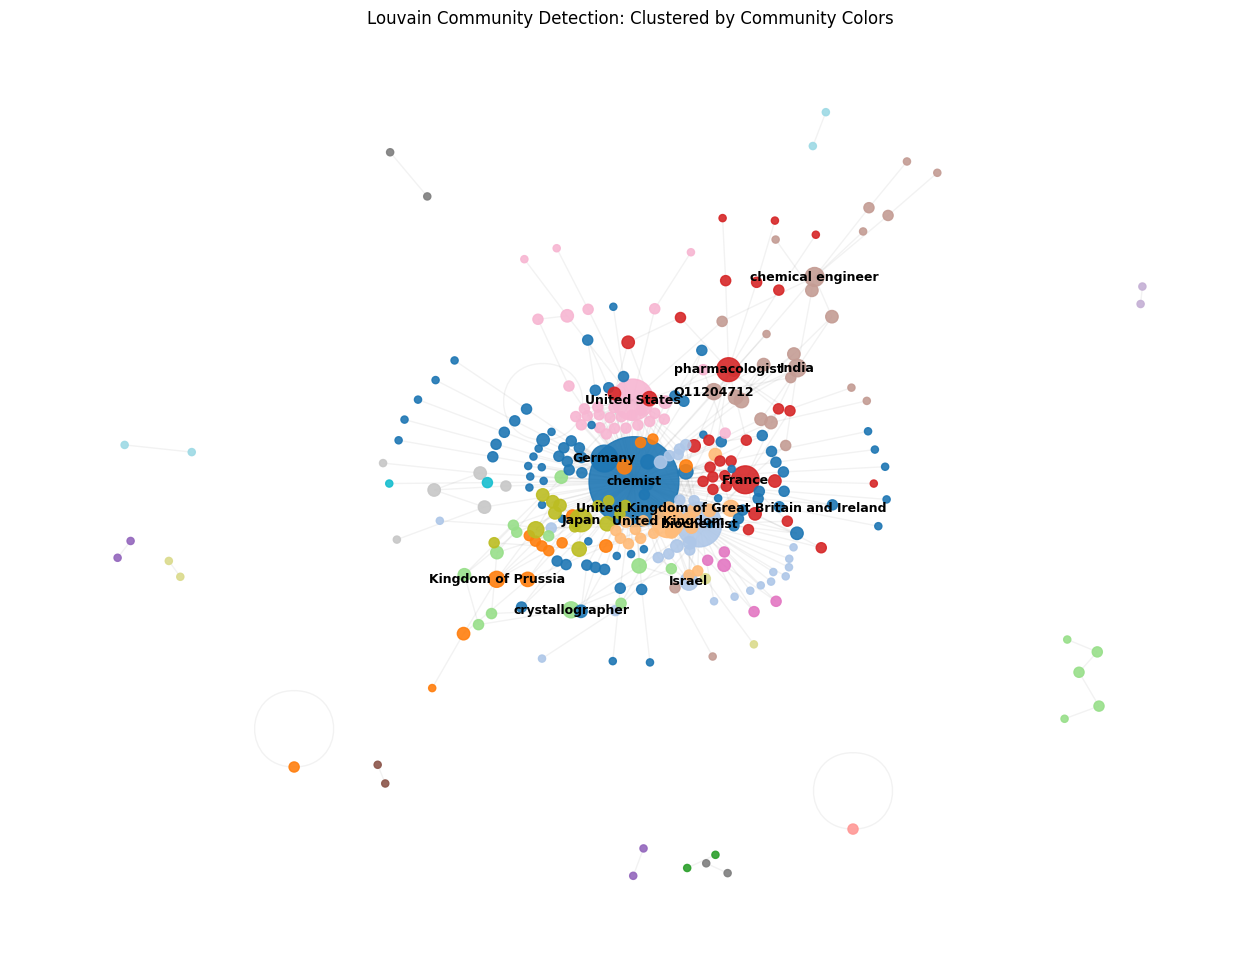

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from community import community_louvain

# Ensure data and helper function are defined in this scope
df = pd.read_csv('/content/chemist.csv')

def get_val(row, title_to_find):
    for i in range(3, 8):
        title_col = f'card-view-title {i}' if i > 3 else 'card-view-title 3'
        val_col = f'card-view-value {i-1}' if i > 3 else 'card-view-value'
        if title_col in row and row[title_col] == title_to_find:
            return row[val_col]
    return None

# Create the network
G_clustered = nx.Graph()
subset_large = df.head(300)

for _, row in subset_large.iterrows():
    name = str(row['explore href']).split('/')[-1]
    country = get_val(row, 'countryLabel')
    occ = get_val(row, 'occupationLabel')

    if country and pd.notna(country):
        G_clustered.add_edge(name, country)
    if occ and pd.notna(occ):
        G_clustered.add_edge(name, occ)

# Clean up network
G_clustered.remove_nodes_from(list(nx.isolates(G_clustered)))

# Community detection using Louvain algorithm
partition = community_louvain.best_partition(G_clustered)

# Centrality for node sizing
centrality = nx.degree_centrality(G_clustered)

# Visualization
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G_clustered, k=0.12, seed=42)

# Generate unique colors for each community
nodes = list(G_clustered.nodes())
node_colors = [partition[n] for n in nodes]
node_sizes = [centrality[n] * 8000 for n in nodes]

# Use a qualitative colormap (tab20) to ensure distinct colors for clusters
nx.draw_networkx_nodes(G_clustered, pos, node_size=node_sizes, cmap=plt.cm.tab20, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G_clustered, pos, alpha=0.1, edge_color='gray')

# Label top hubs
top_hubs = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:15]
labels = {n: n for n, c in top_hubs}
nx.draw_networkx_labels(G_clustered, pos, labels, font_size=9, font_weight='bold')

plt.title('Louvain Community Detection: Clustered by Community Colors')
plt.axis('off')
plt.show()

In [1]:
import community as community_louvain
import numpy as np

# We use a larger subset for better clustering visibility
subset_large = df.head(200)
G_clustered = nx.Graph()

for _, row in subset_large.iterrows():
    name = str(row['explore href']).split('/')[-1]
    country = get_val(row, 'countryLabel')
    occ = get_val(row, 'occupationLabel')

    if country and pd.notna(country):
        G_clustered.add_edge(name, country)
    if occ and pd.notna(occ):
        G_clustered.add_edge(name, occ)

# Remove isolated nodes
G_clustered.remove_nodes_from(list(nx.isolates(G_clustered)))

# Community detection (Louvain)
partition = community_louvain.best_partition(G_clustered)

# Centrality calculation to find 'Interesting' hubs
centrality = nx.degree_centrality(G_clustered)

# Visualization
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G_clustered, k=0.1, iterations=50, seed=123)

# Color nodes by their community
camp = plt.cm.get_cmap('viridis', max(partition.values()) + 1)
nodes = G_clustered.nodes()
node_colors = [partition[n] for n in nodes]

# Node size based on centrality
node_sizes = [centrality[n] * 5000 for n in nodes]

nx.draw_networkx_nodes(G_clustered, pos, node_size=node_sizes,
                       cmap=camp, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G_clustered, pos, alpha=0.2, edge_color='gray')

# Only label the most central 'interesting' nodes (hubs)
top_hubs = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:15]
labels = {n: n for n, c in top_hubs}
nx.draw_networkx_labels(G_clustered, pos, labels, font_size=10, font_weight='bold')

plt.title('Clustered Network: Hubs and Communities in the Biologist Dataset')
plt.axis('off')
plt.show()

print("Top hubs found in the data:", [h[0] for h in top_hubs])

NameError: name 'df' is not defined

### Focused Cluster Analysis
In this section, we refine the network to focus on the most 'interesting' nodes—those with the highest degree centrality (the most connections). This helps us see how major scientific hubs are organized.

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
from community import community_louvain

file_path = '/content/chemist.csv'

if not os.path.exists(file_path):
    print(f"Error: '{file_path}' not found. Please upload the file to the Colab session.")
else:
    # Reload data and define helper to ensure scope is clean
    df = pd.read_csv(file_path)

    def get_val(row, title_to_find):
        for i in range(3, 8):
            title_col = f'card-view-title {i}' if i > 3 else 'card-view-title 3'
            val_col = f'card-view-value {i-1}' if i > 3 else 'card-view-value'
            if title_col in row and row[title_col] == title_to_find:
                return row[val_col]
        return None

    # Build the graph using a larger sample for better connectivity
    G = nx.Graph()
    for _, row in df.head(500).iterrows():
        name = str(row['explore href']).split('/')[-1]
        country = get_val(row, 'countryLabel')
        occ = get_val(row, 'occupationLabel')

        if country and pd.notna(country):
            G.add_edge(name, country)
        if occ and pd.notna(occ):
            G.add_edge(name, occ)

    # Identify 'Interesting' Hubs (Top 5% by degree)
    centrality = nx.degree_centrality(G)
    centrality_values = sorted(centrality.values(), reverse=True)
    threshold = centrality_values[min(int(len(G) * 0.05), len(centrality_values)-1)]
    interesting_nodes = [n for n, c in centrality.items() if c >= threshold]

    # Detect communities
    partition = community_louvain.best_partition(G)

    # Visualization focused on the main structure
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, k=0.15, seed=42)

    # Draw nodes colored by community and sized by importance
    nodes = list(G.nodes())
    node_colors = [partition[n] for n in nodes]
    node_sizes = [centrality[n] * 10000 for n in nodes]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, cmap=plt.cm.Set3, node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')

    # Only label the 'interesting' nodes to avoid clutter
    labels = {n: n for n in interesting_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold')

    plt.title("Clustering Around Major Scientific Hubs (Occupations & Countries)")
    plt.axis('off')
    plt.show()

Error: '/content/chemist.csv' not found. Please upload the file to the Colab session.


### Bridging the Gap: Finding Connectivity Hubs
In this analysis, we look for nodes with high **betweenness centrality**. These are the 'bridges' that connect different clusters (e.g., a chemist who worked in both Germany and the US, or someone who is both a physicist and a biologist).

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
from community import community_louvain

file_path = '/content/chemist.csv'

if not os.path.exists(file_path):
    print("Error: 'chemist.csv' not found. Please upload it to the left sidebar.")
else:
    df = pd.read_csv(file_path)

    def get_val(row, title_to_find):
        for i in range(3, 8):
            title_col = f'card-view-title {i}' if i > 3 else 'card-view-title 3'
            val_col = f'card-view-value {i-1}' if i > 3 else 'card-view-value'
            if title_col in row and row[title_col] == title_to_find:
                return row[val_col]
        return None

    G = nx.Graph()
    # Use 400 rows for a balanced complexity
    for _, row in df.head(400).iterrows():
        name = str(row['explore href']).split('/')[-1]
        country = get_val(row, 'countryLabel')
        occ = get_val(row, 'occupationLabel')
        if country and pd.notna(country): G.add_edge(name, country)
        if occ and pd.notna(occ): G.add_edge(name, occ)

    # Community detection
    partition = community_louvain.best_partition(G)

    # Calculate Betweenness Centrality (The 'Bridges')
    # We use a subset of nodes for faster computation if the graph is large
    bet_centrality = nx.betweenness_centrality(G, k=100, seed=42)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=0.15, seed=42)

    # Node attributes
    nodes = list(G.nodes())
    colors = [partition[n] for n in nodes]
    sizes = [bet_centrality.get(n, 0) * 20000 + 50 for n in nodes]

    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, cmap=plt.cm.RdYlBu, alpha=0.8)
    nx.draw_networkx_edges(G, pos, alpha=0.1)

    # Label only the most important 'Bridge' nodes
    top_bridges = sorted(bet_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
    labels = {n: n for n, v in top_bridges}
    nx.draw_networkx_labels(G, pos, labels, font_size=11, font_weight='bold')

    plt.title("Scientific Bridges: Nodes Connecting Different Communities")
    plt.axis('off')
    plt.show()

    print("Top 10 Bridge Nodes:", [n for n, v in top_bridges])

Error: 'chemist.csv' not found. Please upload it to the left sidebar.


### Cluster Analysis around Major Hubs
This analysis isolates the most connected nodes (hubs) and visualizes how other entities cluster around them using a force-directed layout.

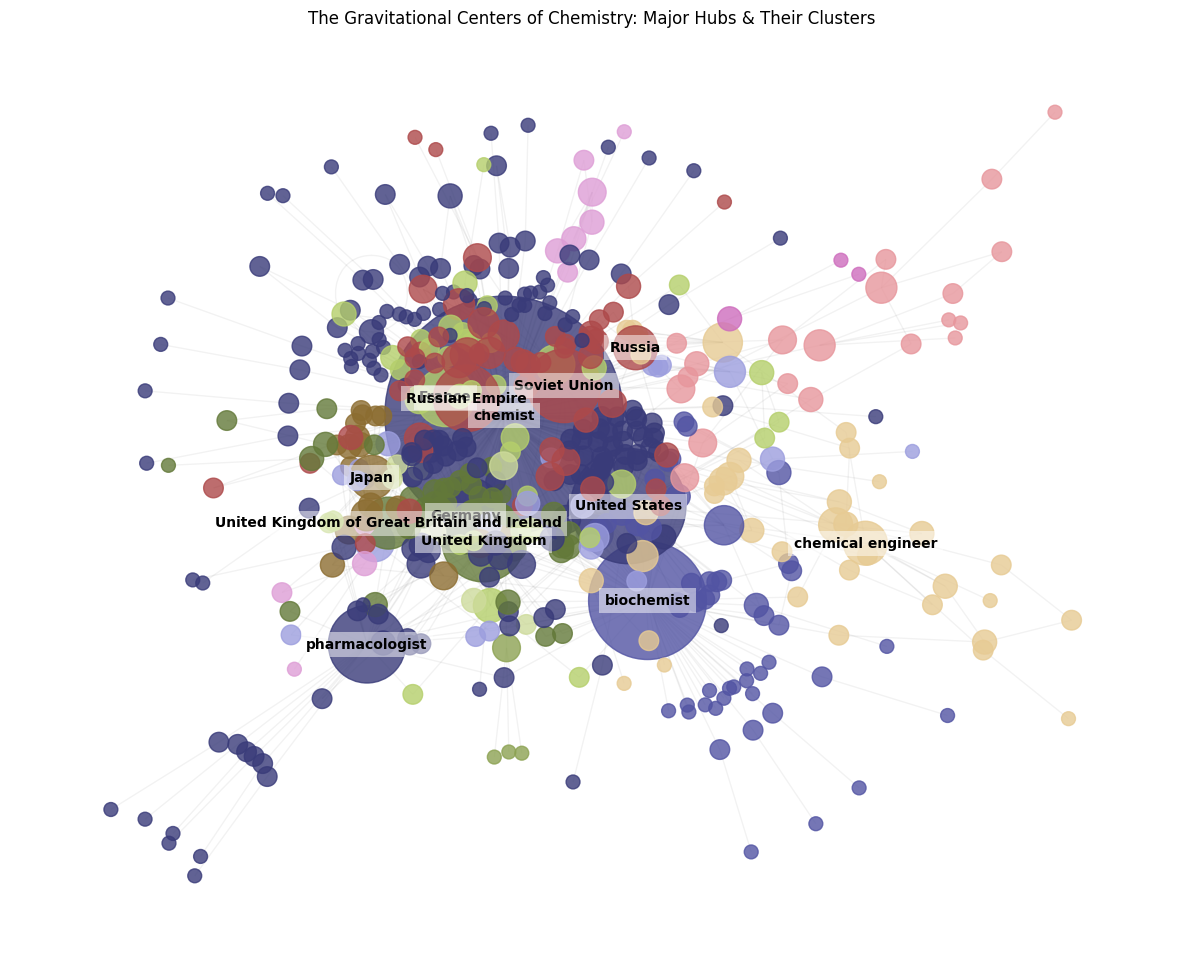

In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from community import community_louvain

# Load data
df = pd.read_csv('/content/chemist.csv')

def get_val(row, title_to_find):
    for i in range(3, 8):
        title_col = f'card-view-title {i}' if i > 3 else 'card-view-title 3'
        val_col = f'card-view-value {i-1}' if i > 3 else 'card-view-value'
        if title_col in row and row[title_col] == title_to_find:
            return row[val_col]
    return None

# Build graph from a larger sample
G = nx.Graph()
for _, row in df.head(600).iterrows():
    name = str(row['explore href']).split('/')[-1]
    country = get_val(row, 'countryLabel')
    occ = get_val(row, 'occupationLabel')

    if country and pd.notna(country):
        G.add_edge(name, country)
    if occ and pd.notna(occ):
        G.add_edge(name, occ)

# Community Detection
partition = community_louvain.best_partition(G)

# Calculate Degree Centrality
degrees = dict(G.degree())

# Filter to show only the largest component for a cleaner 'interesting' view
main_component = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(main_component)

plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G_sub, k=0.1, iterations=100, seed=42)

# Node aesthetics
nodes = G_sub.nodes()
colors = [partition[n] for n in nodes]
sizes = [degrees[n] * 100 for n in nodes]

nx.draw_networkx_nodes(G_sub, pos, node_size=sizes, node_color=colors, cmap=plt.cm.tab20b, alpha=0.8)
nx.draw_networkx_edges(G_sub, pos, alpha=0.05, edge_color='black')

# Label only the massive hubs (degree > some threshold)
hub_threshold = sorted(degrees.values(), reverse=True)[10]
labels = {n: n for n in nodes if degrees[n] >= hub_threshold}
nx.draw_networkx_labels(G_sub, pos, labels, font_size=10, font_weight='bold', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.title("The Gravitational Centers of Chemistry: Major Hubs & Their Clusters")
plt.axis('off')
plt.show()